### 1) Visão Geral do Dataset

O dataset contém 9.895 registros de vendas distribuídos em 6 colunas: `id`, `id_client`, `id_product`, `qtd`, `total` e `sale_date`.

A partir do nome do arquivo e de uma inspeção inicial dos dados, é possível inferir que as vendas ocorreram entre os anos de 2023 e 2024. Porém, não é possível dizer com exatidão o intervalo completo das datas, já que a coluna `sale_date` apresenta formatos inconsistentes.
Algumas datas estão no padrão `yyyy-MM-dd`, enquanto outras `dd-MM-yyyy`. 

In [1]:
import pandas as pd

In [5]:
df_sales = pd.read_csv('../dataset/vendas_2023_2024.csv')
df_sales.head()

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,15-09-2024
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


In [8]:
rows_count, cols_count = df_sales.shape

print(f'Total de linhas: {rows_count}')
print(f'Total de colunas: {cols_count}')

Total de linhas: 9895
Total de colunas: 6


In [10]:
df_sales.dtypes

id              int64
id_client       int64
id_product      int64
qtd             int64
total         float64
sale_date         str
dtype: object

### 2) Análise de Valores Númericos

A coluna `total`, que representa o valor das vendas, apresenta a seguinte distribuição:
- Valor mínimo: 294,50
- Valor máximo: 2.222.973,00
- Valor médio: 263.797,83

In [16]:
df_sales['total'].agg(['min', 'max', 'mean']).map('{:.2f}'.format)

min         294.50
max     2222973.00
mean     263797.83
Name: total, dtype: str

### 3) Interpretação

A análise exploratória indica que o dataset apresenta uma boa integridade estrutural inicial. Já que não há valores nulos, os registros não apresentam duplicidade e os identificadores são únicos (valores de `id` não se repetem).

No entanto, alguns pontos de atenção foram identificados.

Primeiramente, a coluna `sale_date` não possui padronização no formato das datas, o que impede análises temporais e exigiria tratamento prévio.

Além disso, aplicando o método Interquartile Range (IQR) para a coluna `total`, foram identificados 1.018 registros que se enquadram como outliers. Esses valores podem representar inconsistências nos dados ou transações verdadeiras de alto valor, portanto devem ser investigados mais a fundo.

Portanto, apesar do dataset apresentar boa integridade estrutural, ele ainda não está totalmente pronto para análises mais profundas. Antes disso, é recomendável padronizar a coluna `sale_date` e checar os registros classificados como outliers.

In [32]:
df_sales['id'].is_unique

True

In [31]:
df_sales.duplicated(subset=['id_client', 'id_product', 'qtd', 'total', 'sale_date']).any()

np.False_

In [22]:
df_sales.isna().any()

id            False
id_client     False
id_product    False
qtd           False
total         False
sale_date     False
dtype: bool

<Axes: >

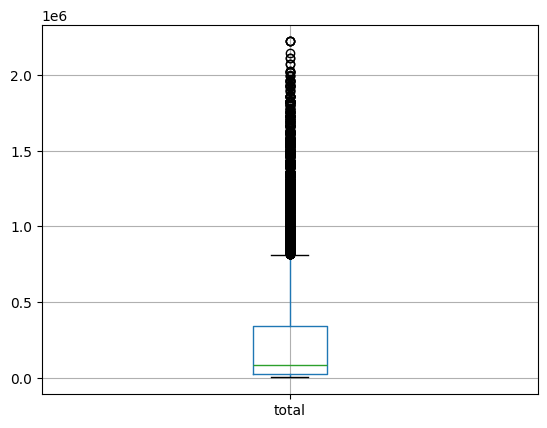

In [27]:
df_sales.boxplot('total')

In [30]:
Q1 = df_sales['total'].quantile(0.25)
Q3 = df_sales['total'].quantile(0.75)

IQR = Q3 - Q1

df_sales['is_outlier'] = (
    (df_sales['total'] < Q1 - 1.5 * IQR) |
    (df_sales['total'] > Q3 + 1.5 * IQR)
)

len(df_sales[df_sales['is_outlier']])

1018